# Detector threshold sensitivity analysis

What each detector's threshold costs and buys, measured rather than asserted.

The numbers come from `research/sweep_metrics.csv` and
`research/case_outcomes.csv`, written by
`uv run python scripts/run_sensitivity_sweep.py`. The method — what the corpus
is, how cases are labelled, and why the window axis is each detector's own
`time_window_seconds` rather than the shared evaluation interval — is in
`docs/SENSITIVITY_ANALYSIS.md`. The conclusions and the recommended defaults
are in `docs/DETECTION_TUNING.md`.

This notebook is the working between them. Run it with:

```bash
uv sync --all-groups
uv run jupyter lab notebooks/detection_analysis.ipynb
```

Everything it computes comes from `scripts/sensitivity/`, so the tables here
and the figures in `docs/images/` cannot disagree.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

from sensitivity.analysis import (
    EVALUATION_INTERVAL,
    load_metrics,
    load_outcomes,
    shipped_operating_points,
    shipped_windows,
    window_sensitivity,
)
from sensitivity.corpus import CORPUS
from sensitivity.recommendation import best_f1_points

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)

metrics = load_metrics()
outcomes = load_outcomes()
windows = shipped_windows()
print(f"{len(metrics):,} grid points over {len(CORPUS)} cases")
print(f"evaluation interval: {EVALUATION_INTERVAL:g}s")

791 grid points over 49 cases
evaluation interval: 5s


## 1. The corpus

Half the corpus is benign traffic shaped like an attack. Without it every
precision figure would be 1.0 by construction — there would be nothing present
that *could* be mistaken for an attack.

In [2]:
composition = pd.DataFrame(
    [
        {"family": case.family, "case": case.name, "labelled_for": ", ".join(sorted(case.expected)) or "—"}
        for case in CORPUS
    ]
)
composition.groupby("family").agg(
    cases=("case", "count"),
    positives=("labelled_for", lambda column: (column != "—").sum()),
)

,cases,positives
family,,
arp,3,2
baseline,3,1
beaconing,6,3
credentials,7,4
dns,5,2
exfiltration,8,4
flood,10,6
recon,7,4


## 2. What ships

The configured threshold at the configured window. That is only a meaningful
pair since Milestone 21: before it, `time_window_seconds` was declared,
validated and read by nothing. Every detector's real window was whatever
`detection.evaluation_interval_seconds` happened to be, because `evaluate()`
cleared the detector's state and `PeriodicEvaluator` called it on one shared
timer. A detector configured to watch an hour watched five seconds.

An empty `f1` means the detector never fired at all: it has no precision, so
there is no balance to strike. There are none left.

In [3]:
shipped = shipped_operating_points(metrics)
shipped[
    ["threshold", "true_positives", "false_positives", "false_negatives", "precision", "recall", "f1"]
]

,threshold,true_positives,false_positives,false_negatives,precision,recall,f1
detector,,,,,,,
ArpSpoofingDetector,5,2,1,0,0.666667,1.000000,0.800000
BeaconingDetector,10,3,2,0,0.600000,1.000000,0.750000
DataExfiltrationDetector,50000000,1,1,1,0.500000,0.500000,0.500000
DnsTunnelingDetector,50,1,1,1,0.500000,0.500000,0.500000
HttpBruteForceDetector,20,1,0,1,1.000000,0.500000,0.666667
IcmpFloodDetector,20,2,0,0,1.000000,1.000000,1.000000
LateralMovementDetector,20,1,0,1,1.000000,0.500000,0.666667
SshBruteForceDetector,12,1,0,1,1.000000,0.500000,0.666667
SynFloodDetector,40,2,0,0,1.000000,1.000000,1.000000


No detector is silent any more. Before the window fix, five of the twelve had
a recall of 0.00 against their own attacks and three more sat at or below 0.5 —
not because their thresholds were wrong, but because each was configured for a
window of 60 to 3600 seconds and run with a window of five.

The table below is the whole of the fix, measured. The middle column is the
old thresholds with the windows working; the difference between it and the
left column is what the bug cost, and none of it needed a threshold change.

In [4]:
from sensitivity.detectors import shipped_value
from sensitivity.grid import THRESHOLDS
from sensitivity.proposal import PREVIOUS_THRESHOLDS


def recall_at(per_detector_window: dict[str, float], overrides: dict[str, int]) -> pd.Series:
    """Recall for every swept detector at one (window, threshold) choice each."""
    scores = {}
    for detector, (parameter, _) in THRESHOLDS.items():
        threshold = overrides.get(detector, shipped_value(detector, parameter))
        row = metrics[
            (metrics["detector"] == detector)
            & (metrics["window_seconds"] == per_detector_window[detector])
            & (metrics["threshold"] == threshold)
        ]
        scores[detector] = float(row["recall"].iloc[0]) if len(row) else float("nan")
    return pd.Series(scores)


broken = dict.fromkeys(THRESHOLDS, EVALUATION_INTERVAL)
cost_of_the_bug = pd.DataFrame(
    {
        "window ignored (5s)": recall_at(broken, PREVIOUS_THRESHOLDS),
        "window honoured": recall_at(windows, PREVIOUS_THRESHOLDS),
        "window honoured + retuned": recall_at(windows, {}),
    }
)
print(cost_of_the_bug.mean().round(3).to_string())
cost_of_the_bug.round(2)

window ignored (5s)          0.410
window honoured              0.618
window honoured + retuned    0.743


,window ignored (5s),window honoured,window honoured + retuned
TcpPortScanDetector,0.25,0.75,0.75
SynScanDetector,0.67,0.67,0.67
SynFloodDetector,1.00,0.50,1.00
UdpFloodDetector,1.00,0.50,1.00
IcmpFloodDetector,1.00,0.50,1.00
SshBruteForceDetector,0.50,0.50,0.50
HttpBruteForceDetector,0.00,0.50,0.50
ArpSpoofingDetector,0.50,1.00,1.00
DnsTunnelingDetector,0.00,0.50,0.50
BeaconingDetector,0.00,1.00,1.00


## 3. The window dominates the threshold

The best F1 each detector can reach at each window. Read across a row: if the
row is flat, the detector is tunable by threshold alone. If it climbs, no
threshold rescues it — the window is the binding constraint.

In [5]:
sensitivity = window_sensitivity(metrics)
sensitivity.round(2)

window_seconds,1.0,5.0,10.0,30.0,60.0,300.0,3600.0
detector,,,,,,,
ArpSpoofingDetector,0.80,0.80,0.80,0.80,0.80,0.80,0.80
BeaconingDetector,NaN,NaN,NaN,0.50,0.50,0.75,0.75
DataExfiltrationDetector,NaN,0.67,0.67,0.67,0.80,0.80,0.80
DnsTunnelingDetector,NaN,0.50,0.67,0.80,0.80,0.80,0.80
HttpBruteForceDetector,0.67,0.67,0.67,0.80,0.80,0.80,0.80
IcmpFloodDetector,1.00,1.00,1.00,1.00,0.80,0.80,0.80
LateralMovementDetector,NaN,0.67,0.80,0.67,0.80,0.80,0.80
SshBruteForceDetector,0.67,0.80,0.67,0.67,0.67,0.80,0.80
SynFloodDetector,1.00,0.80,0.80,0.80,0.80,0.80,0.80


In [6]:
cost_of_the_window = pd.DataFrame(
    {
        "configured_window": pd.Series(windows),
        "f1_at_configured": pd.Series(
            {name: sensitivity.loc[name, windows[name]] for name in sensitivity.index}
        ),
        "best_f1_any_window": sensitivity.max(axis=1),
    }
)
cost_of_the_window["gap"] = (
    cost_of_the_window["best_f1_any_window"] - cost_of_the_window["f1_at_configured"]
)
# A missing f1_at_configured would not be a small gap, it would be the largest
# one: the detector never fired at its own window, so it has no score to be
# behind by. There are none, which is itself the result.
cost_of_the_window.sort_values("gap", ascending=False, na_position="first").round(2)

,configured_window,f1_at_configured,best_f1_any_window,gap
SshBruteForceDetector,60.0,0.67,0.80,0.13
SynScanDetector,10.0,0.80,0.86,0.06
TcpPortScanDetector,10.0,0.86,0.89,0.03
ArpSpoofingDetector,60.0,0.80,0.80,0.00
DnsTunnelingDetector,60.0,0.80,0.80,0.00
DataExfiltrationDetector,60.0,0.80,0.80,0.00
BeaconingDetector,3600.0,0.75,0.75,0.00
HttpBruteForceDetector,60.0,0.80,0.80,0.00
LateralMovementDetector,60.0,0.80,0.80,0.00
IcmpFloodDetector,1.0,1.00,1.00,0.00


## 4. Where each detector is best

Ties are broken toward the higher threshold and then the shorter window: among
configurations that score the same, prefer the one that alerts less and decides
sooner.

In [7]:
best = best_f1_points(metrics)
best[["parameter", "threshold", "window_seconds", "precision", "recall", "false_positive_rate", "f1"]]

,parameter,threshold,window_seconds,precision,recall,false_positive_rate,f1
detector,,,,,,,
ArpSpoofingDetector,gratuitous_arp_threshold,6,30.0,0.666667,1.0,0.021277,0.800000
BeaconingDetector,connection_count_threshold,15,3600.0,0.600000,1.0,0.043478,0.750000
DataExfiltrationDetector,bytes_out_threshold,30000000,60.0,0.666667,1.0,0.021277,0.800000
DnsTunnelingDetector,query_count_threshold,30,60.0,0.666667,1.0,0.021277,0.800000
HttpBruteForceDetector,connection_count_threshold,12,300.0,0.666667,1.0,0.021277,0.800000
IcmpFloodDetector,icmp_count_threshold,50,5.0,1.000000,1.0,0.000000,1.000000
LateralMovementDetector,internal_connection_threshold,15,300.0,0.666667,1.0,0.021277,0.800000
SshBruteForceDetector,connection_count_threshold,8,300.0,0.666667,1.0,0.021277,0.800000
SynFloodDetector,syn_count_threshold,40,1.0,1.000000,1.0,0.000000,1.000000


In [8]:
comparison = pd.DataFrame(
    {
        "shipped_threshold": shipped["threshold"],
        "shipped_window": pd.Series(windows),
        "best_threshold": best["threshold"],
        "best_window": best["window_seconds"],
        "shipped_f1": shipped["f1"],
        "best_f1": best["f1"],
    }
).round(3)
comparison

,shipped_threshold,shipped_window,best_threshold,best_window,shipped_f1,best_f1
ArpSpoofingDetector,5,60.0,6,30.0,0.800,0.800
BeaconingDetector,10,3600.0,15,3600.0,0.750,0.750
DataExfiltrationDetector,50000000,60.0,30000000,60.0,0.500,0.800
DnsTunnelingDetector,50,60.0,30,60.0,0.500,0.800
HttpBruteForceDetector,20,60.0,12,300.0,0.667,0.800
IcmpFloodDetector,20,1.0,50,5.0,1.000,1.000
LateralMovementDetector,20,60.0,15,300.0,0.667,0.800
SshBruteForceDetector,12,60.0,8,300.0,0.667,0.800
SynFloodDetector,40,1.0,40,1.0,1.000,1.000
SynScanDetector,10,10.0,12,300.0,0.800,0.857


## 5. What is actually being missed, and mistaken

An aggregate that says recall dropped is not actionable until you know which
case it started missing. `case_outcomes.csv` holds that: for each detector,
window and case, the highest threshold at which the detector still fired.

At the best window and threshold for each detector, these are the cases it
gets wrong.

In [9]:
def mistakes(detector: str) -> pd.DataFrame:
    """Cases this detector misses or falsely reports, at its best operating point."""
    row = best.loc[detector]
    at_point = outcomes[
        (outcomes["detector"] == detector) & (outcomes["window_seconds"] == row["window_seconds"])
    ].copy()
    at_point["fired"] = at_point["highest_firing_threshold"] >= row["threshold"]
    wrong = at_point[at_point["fired"] != at_point["expected"].astype(bool)]
    return wrong[["case", "family", "expected", "fired"]]


pd.concat(
    {detector: mistakes(detector) for detector in best.index},
    names=["detector"],
).droplevel(1)

,case,family,expected,fired
detector,,,,
ArpSpoofingDetector,arp_housekeeping_9,arp,0,True
BeaconingDetector,telemetry_agent_60s_20,beaconing,0,True
BeaconingDetector,healthcheck_poll_10s_40,beaconing,0,True
DataExfiltrationDetector,backup_upload_60mb,exfiltration,0,True
DnsTunnelingDetector,reputation_lookups_80q,dns,0,True
HttpBruteForceDetector,sso_portal_18,credentials,0,True
LateralMovementDetector,snmp_poll_18_hosts,exfiltration,0,True
SshBruteForceDetector,config_mgmt_ssh_14,credentials,0,True
SynScanDetector,service_inventory_14ports,recon,0,True


Every row is a false positive; not one is a miss. That is the F1 optimum's
whole character — it reaches recall 1.0 everywhere and pays for it in
precision, and on a corpus that is half attacks the bill barely shows up in
the score. Section 9 lays the same configuration on a clock, where it does.

Nothing in the table is a surprise, and most of it is not fixable with a
threshold at all. `healthcheck_poll_10s_40` and `telemetry_agent_60s_20` are
as regular as any beacon and reach the same count; `reputation_lookups_80q` —
an endpoint agent doing encoded reputation lookups — is byte for byte the
shape of a DNS tunnel; `backup_upload_60mb` is a bulk transfer to an internal
server, which the exfiltration detector documents itself as having no opinion
about; `snmp_poll_18_hosts` fans out to eighteen internal hosts exactly as a
lateral sweep does. They are in the corpus so the measured precision says so
rather than assuming it away, and section 9 records what signal each would
actually need.

## 6. Precision and recall against threshold

One panel per detector; twelve series on one pair of axes would be past every
colour-separation floor, and the question is about one detector at a time.
Thresholds are drawn at even spacing — the grids are dense around the shipped
value and sparse at the extremes, and plotting them to scale would push the
interesting region into the left margin.

First, at each detector's configured window — what production runs.

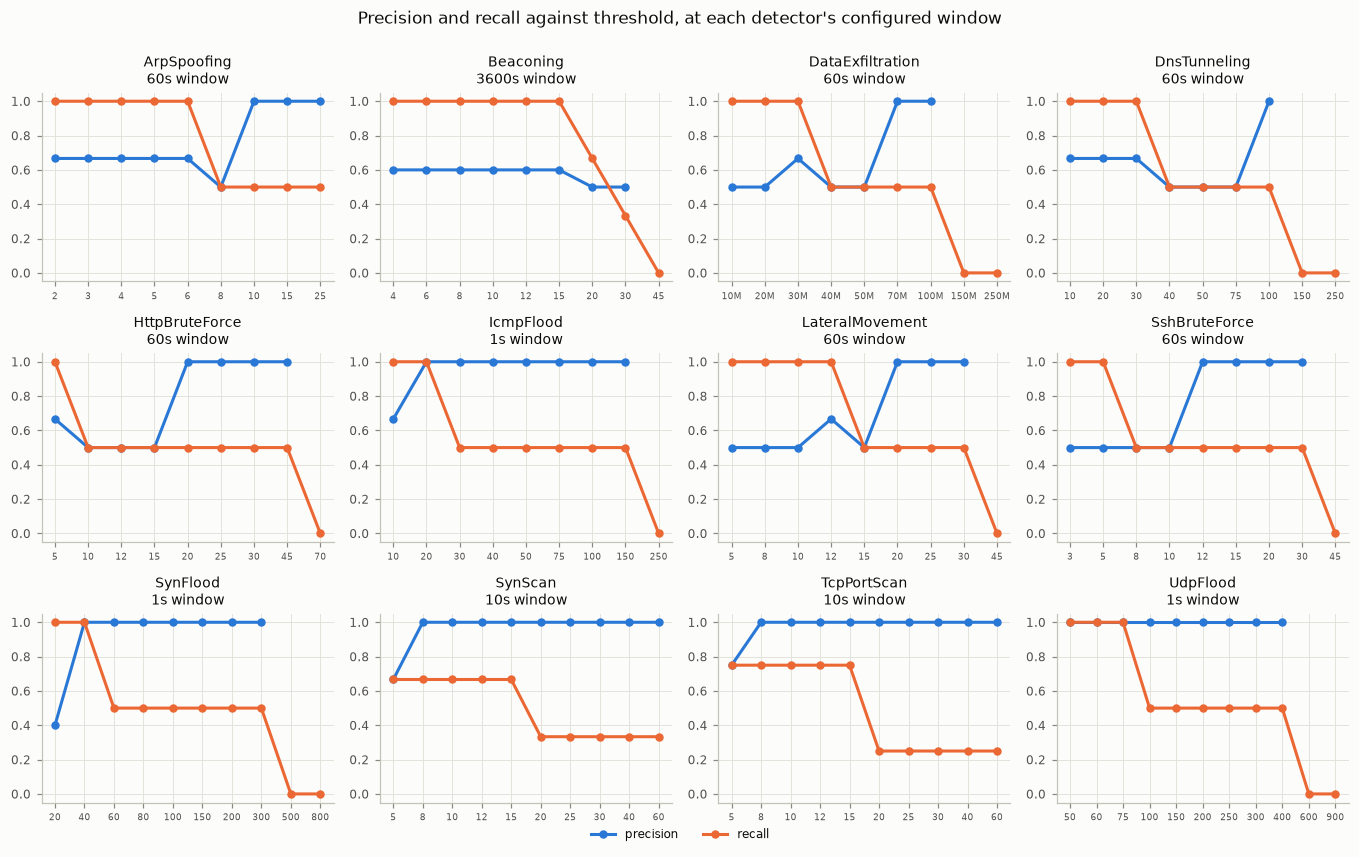

In [10]:
%matplotlib inline

from sensitivity.grid import WINDOWS
from sensitivity.plots_curves import precision_recall_grid, roc_grid
from sensitivity.style import apply_style

apply_style()

shipped_curves = precision_recall_grid(
    metrics,
    windows,
    "Precision and recall against threshold, at each detector's configured window",
)

Read the orange lines. Every panel now starts at a recall the threshold can
move; before the window fix five of them sat flat on zero across the whole
range, so the number an operator was invited to tune did nothing at all.

Now the same panels with each detector at whatever window scores highest,
which is not always the one it asks for.

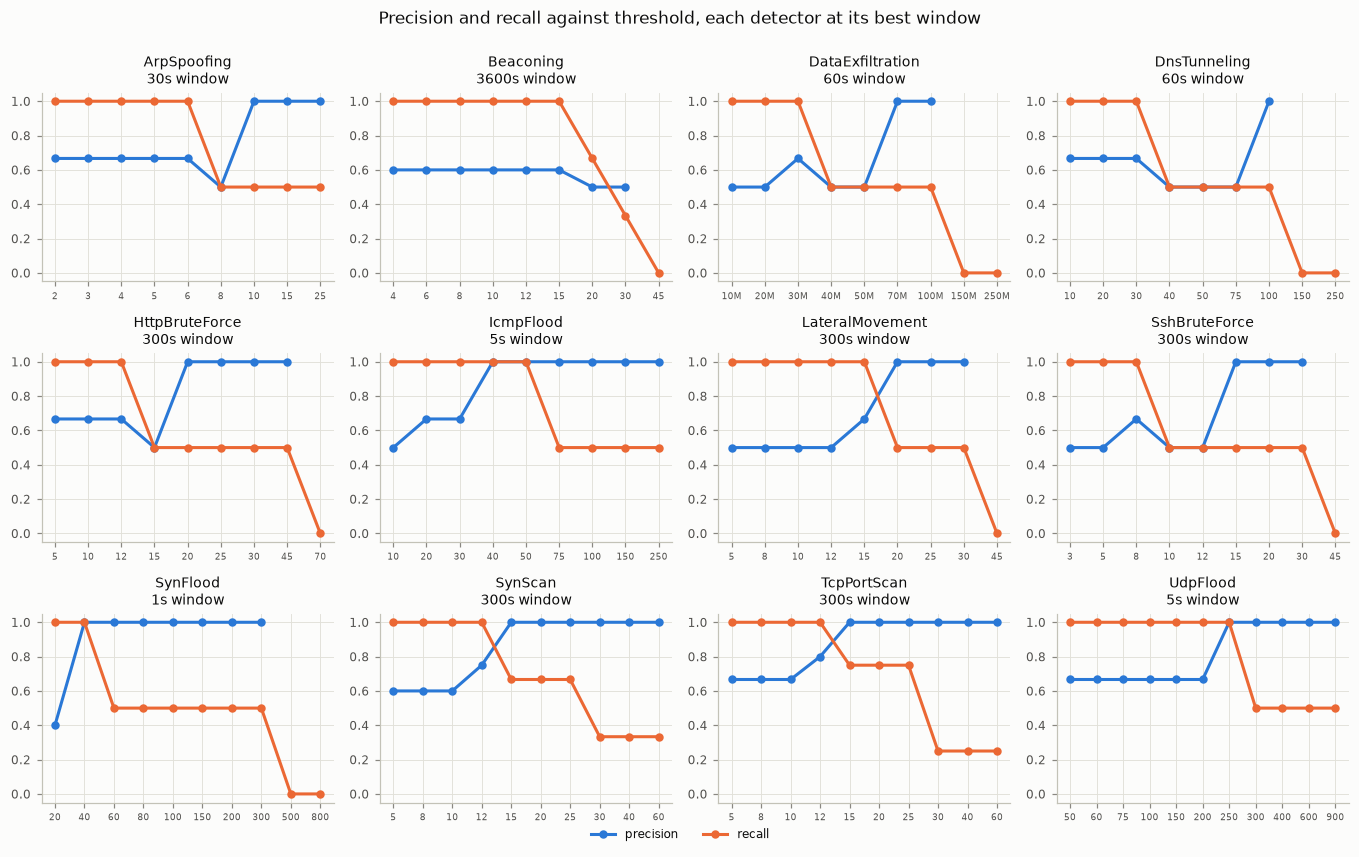

In [11]:
best_curves = precision_recall_grid(
    metrics,
    {name: float(best.loc[name, "window_seconds"]) for name in best.index},
    "Precision and recall against threshold, each detector at its best window",
)

The two figures are close, and that is the result. No detector's configured
window costs it more than 0.13 F1 against a search over seven alternatives,
and the three that give up anything at all — SSH brute force, and the two port
scanners — would buy it with a five-minute window in place of sixty or ten
seconds. The configured windows were chosen from what each attack actually
looks like, and with them honoured they hold up against the search.

## 7. ROC-style curves

Recall against false-positive rate, one curve per window, with the window
encoded as an ordered ramp rather than as categorical colour — it is a
quantity, and light-to-dark reads as ordered without a legend lookup.

There is no chance diagonal. Every false-positive rate here is under 0.06,
because the corpus has forty-odd negative cases and a detector alerts on at
most two of them; on an axis clipped that far, a diagonal is not the chance
line, it is a line at the wrong slope inviting the wrong comparison.

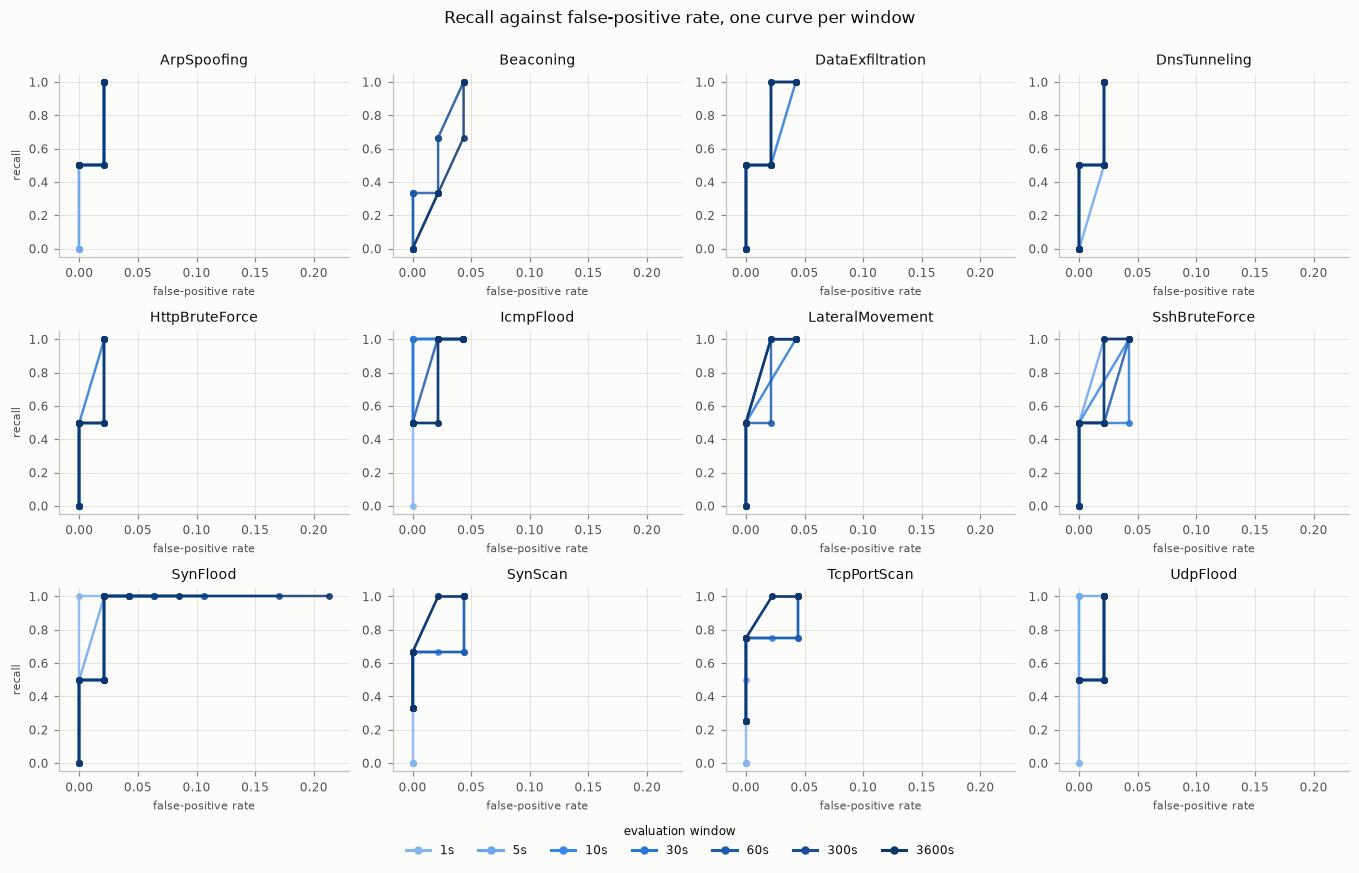

In [12]:
roc_curves = roc_grid(metrics, WINDOWS, "Recall against false-positive rate, one curve per window")

The dark curves sit above and to the left of the light ones in most panels,
which is the same finding the tables give: lengthening the window buys recall
at very little cost in false positives. The flood detectors are the exception
in the other direction — their light curves are already in the top-left corner,
because a flood is defined by rate and a longer window dilutes it. That is why
their configured window is one second and why it should stay there.

Both figures are written to `docs/images/` by
`uv run python scripts/make_sensitivity_figures.py`.

## 8. Parameter sensitivity

The curves above hold the window fixed and vary the threshold. This varies
both, which is the only way to see which of the two the result is actually
sensitive to.

Colour is a single hue, light to dark, because F1 is a magnitude — a rainbow
would imply the middle of the range is a different *kind* of result rather
than a smaller one. Grey cells are not zero: they are configurations where the
detector never fired, so it has no score. The outlined row is the threshold
that ships today.

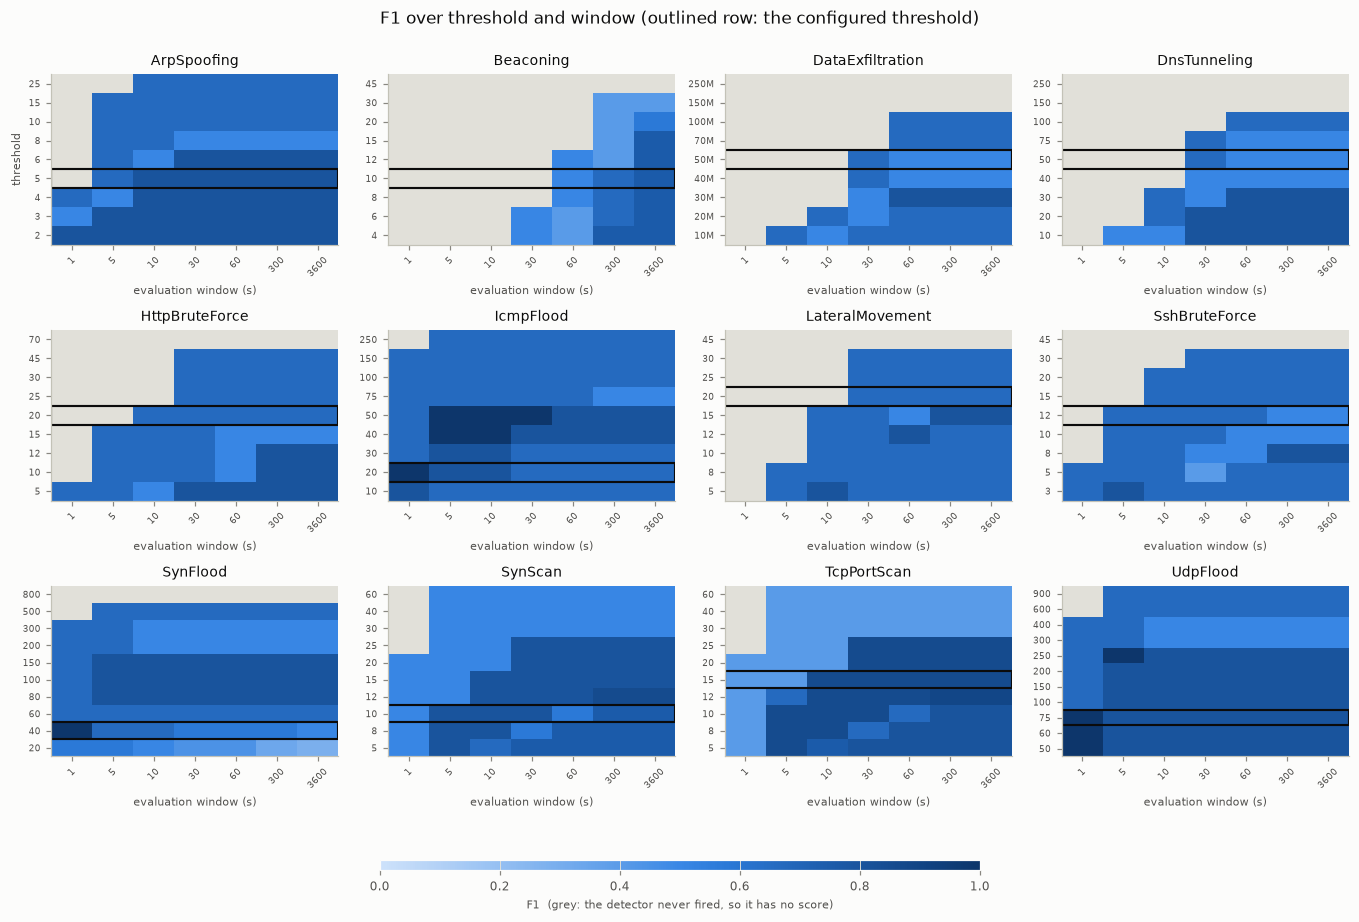

In [13]:
from sensitivity.grid import THRESHOLDS as GRIDS
from sensitivity.plots_heatmaps import f1_heatmaps

heatmaps = f1_heatmaps(
    metrics,
    {name: float(shipped_value(name, parameter)) for name, (parameter, _) in GRIDS.items()},
    "F1 over threshold and window (outlined row: the configured threshold)",
)

Read the gradient direction. In most panels it runs left to right — along the
window — rather than up and down along the threshold, which was the finding
before the fix and survives it: for most of these detectors the window is the
dominant parameter and the threshold is the fine adjustment. The floods are
the exception, and they run the other way: a flood is defined by rate, so a
longer window dilutes it and their gradient falls to the right.

What changed is where production sits on that gradient. The outlined row used
to cross grey or near-grey cells at the left edge, because the left edge was
where every detector ran regardless of what it asked for. Each detector now
sits at its own column, and the grey at the left edge is only a statement
about windows nothing uses.

## 9. What an analyst would actually see

Every number above is measured case by case, in isolation. That is what makes
precision and recall well-defined, and it is not what an operator experiences.
This section lays the same cases end to end on one clock — half an hour of
benign traffic with five attacks placed inside it — and asks how many alerts
arrive, when, and how many of them were about anything.

Three configurations over identical packets: the thresholds that shipped
before this pass, the point the sweep scores highest, and the one this
analysis proposes and `config/detectors.json` now carries. The middle one is
included because it is the obvious reading of the sweep, and it is wrong.

All three run at the same evaluation interval. Since the windows work, the
interval is no longer a detection parameter — it decides how soon an alert can
surface, not whether it is found — so varying it here would only vary the
x-axis.

In [14]:
from sensitivity.plots_timeline import alert_volume
from sensitivity.recommendation import benign_ceiling, clean_points
from sensitivity.scenario import DURATION, attack_spans

# The most sensitive threshold that alerts on no benign case, at each
# detector's own window. Absent detectors have no such threshold: their benign
# and malicious ranges overlap, so no number separates them.
clean = clean_points(metrics, windows)
clean[["threshold", "true_positives", "false_negatives", "recall"]]

,threshold,true_positives,false_negatives,recall
detector,,,,
ArpSpoofingDetector,10,1,1,0.500000
DataExfiltrationDetector,70000000,1,1,0.500000
DnsTunnelingDetector,100,1,1,0.500000
HttpBruteForceDetector,20,1,1,0.500000
IcmpFloodDetector,20,2,0,1.000000
LateralMovementDetector,20,1,1,0.500000
SshBruteForceDetector,12,1,1,0.500000
SynFloodDetector,40,2,0,1.000000
SynScanDetector,8,2,1,0.666667


In [15]:
choices = pd.DataFrame(
    {
        "shipped": pd.Series(
            {name: shipped_value(name, parameter) for name, (parameter, _) in GRIDS.items()}
        ),
        "highest F1": best["threshold"],
        "no false positive": clean["threshold"],
        "busiest benign case": benign_ceiling(outcomes, windows),
    }
)
# Headroom is the point. A threshold sitting on the busiest benign case in the
# corpus is a number fitted to one fixture, not a recommendation. A margin
# below 1.0 means the shipped threshold is *under* the busiest benign case and
# alerts on it by design — every detector in that state is one of the five
# named below, where the ranges overlap and no threshold separates them.
choices["margin"] = choices["shipped"] / choices["busiest benign case"]
choices.round(2)

,shipped,highest F1,no false positive,busiest benign case,margin
ArpSpoofingDetector,5,6,10.0,8.0,0.62
BeaconingDetector,10,15,NaN,30.0,0.33
DataExfiltrationDetector,50000000,30000000,70000000.0,50000000.0,1.00
DnsTunnelingDetector,50,30,100.0,75.0,0.67
HttpBruteForceDetector,20,12,20.0,15.0,1.33
IcmpFloodDetector,20,50,20.0,10.0,2.00
LateralMovementDetector,20,15,20.0,15.0,1.33
SshBruteForceDetector,12,8,12.0,10.0,1.20
SynFloodDetector,40,40,40.0,20.0,2.00
SynScanDetector,10,12,8.0,5.0,2.00


In [16]:
# The per-case magnitudes the proposal is argued from: for each detector at
# its own window, the largest threshold each case still fires at.
at_window = outcomes[
    outcomes.apply(lambda row: windows.get(row["detector"]) == row["window_seconds"], axis=1)
    & outcomes["highest_firing_threshold"].notna()
]
at_window.sort_values(
    ["detector", "highest_firing_threshold"], ascending=[True, False]
).set_index(["detector", "case"])[["expected", "highest_firing_threshold"]]

expected  highest_firing_threshold
detector                 case                                                        
ArpSpoofingDetector      arp_spoof_heavy_30               1                      25.0
                         arp_housekeeping_9               0                       8.0
                         arp_spoof_light_6                1                       6.0
BeaconingDetector        beacon_5s_30                     1                      30.0
                         healthcheck_poll_10s_40          0                      30.0
                         beacon_60s_20                    1                      20.0
                         telemetry_agent_60s_20           0                      20.0
                         beacon_30s_18_jittered           1                      15.0
DataExfiltrationDetector exfil_120mb                      1               100000000.0
                         backup_upload_60mb               0                50000000.0
                         exfil_30mb                       1                30000000.0
                         video_call_25mb                  0                20000000.0
DnsTunnelingDetector     dns_tunnel_120q                  1                     100.0
                         reputation_lookups_80q           0                      75.0
                         dns_tunnel_30q                   1                      30.0
HttpBruteForceDetector   http_brute_fast_60               1                      45.0
                         sso_portal_18                    0                      15.0
                         http_brute_slow_12               1                       5.0
IcmpFloodDetector        icmp_flood_heavy                 1                     150.0
                         icmp_flood_moderate              1                      20.0
                         traceroute_burst_30              0                      10.0
LateralMovementDetector  lateral_smb_40                   1                      30.0
                         snmp_poll_18_hosts               0                      15.0
                         lateral_smb_15                   1                      12.0
                         config_mgmt_ssh_14               0                      10.0
SshBruteForceDetector    ssh_brute_fast_40                1                      30.0
                         config_mgmt_ssh_14               0                      10.0
                         ssh_brute_slow_8                 1                       5.0
                         ci_runner_ssh_6                  0                       5.0
SynFloodDetector         syn_flood_heavy                  1                     300.0
                         syn_flood_moderate               1                      40.0
                         scan_aggressive_60ports          0                      20.0
                         busy_web_server_300              0                      20.0
                         fileserver_clients_30            0                      20.0
SynScanDetector          scan_aggressive_60ports          1                      60.0
                         scan_moderate_25ports            1                      15.0
                         lb_backend_probe_10ports         0                       5.0
TcpPortScanDetector      scan_aggressive_60ports          1                      60.0
                         scan_moderate_25ports            1                      15.0
                         scan_ack_25ports                 1                      15.0
                         lb_backend_probe_10ports         0                       5.0
UdpFloodDetector         udp_flood_heavy                  1                     400.0
                         udp_flood_moderate               1                      75.0

In [17]:
from sensitivity.proposal import (
    PREVIOUS_THRESHOLDS as WAS,
)
from sensitivity.proposal import (
    PROPOSED_INTERVAL,
    PROPOSED_THRESHOLDS,
    UNSEPARABLE_BY_THRESHOLD,
)

print(f"proposed interval: {PROPOSED_INTERVAL:g}s")
for detector, value in PROPOSED_THRESHOLDS.items():
    print(f"  {detector:26s} {WAS[detector]:>10,d} -> {value:,d}")
print()
for detector, reason in UNSEPARABLE_BY_THRESHOLD.items():
    print(detector)
    print(f"    {reason}")
    print()

proposed interval: 5s
  SynFloodDetector                  100 -> 40
  IcmpFloodDetector                  50 -> 20
  UdpFloodDetector                  200 -> 75
  SshBruteForceDetector              10 -> 12

BeaconingDetector
    A health check every ten seconds is as regular as a beacon and reaches the same count. Needs destination reputation or a known-good list, not a different count.

DnsTunnelingDetector
    Encoded reputation lookups reach 75 queries a minute; the tunnel reaches 100. Needs a registered-domain allowlist.

DataExfiltrationDetector
    A nightly backup moves 50 MB and a staged archive 30 MB. Needs the destination — internal, known-good, or neither.

ArpSpoofingDetector
    Duplicate-address detection after a lease renewal reaches 8 packets and a light poisoner 6. The shipped threshold of 5 alerts on both, and is kept: ARP poisoning is worth a false positive that one MAC allowlist entry removes, and raising it to clear the overlap would lose the quiet half of the atta

In [18]:
timeline = pd.read_csv("../research/alert_timeline.csv")
timeline.pivot_table(
    index="config", columns="attributable", values="detector", aggfunc="count"
).rename(columns={0: "nothing was happening", 1: "an attack was running"})

attributable,nothing was happening,an attack was running
config,,
highest F1,8,6
previous thresholds,5,5
recommended,1,6


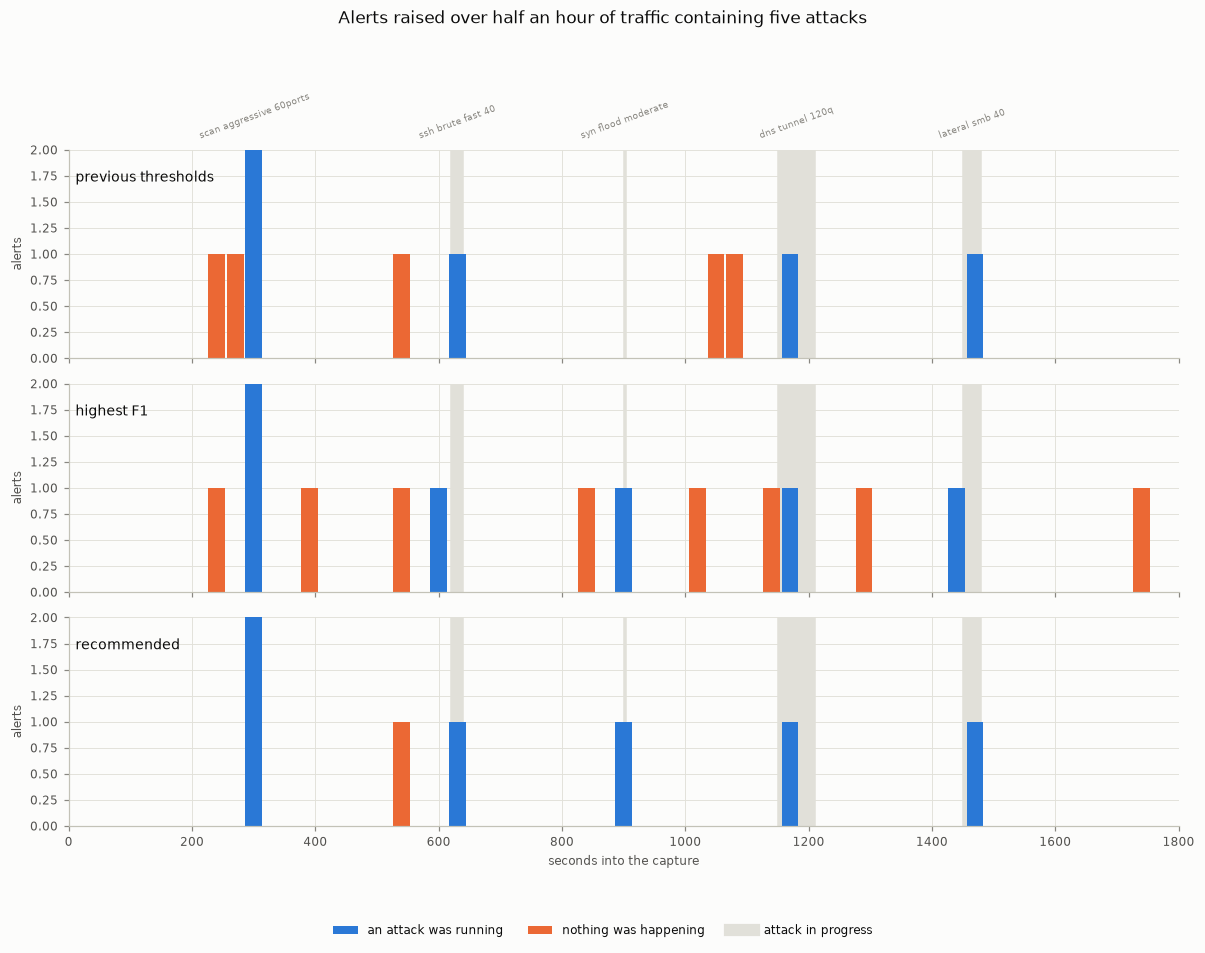

In [19]:
volume = alert_volume(
    timeline,
    attack_spans(),
    DURATION,
    "Alerts raised over half an hour of traffic containing five attacks",
)

This is the finding the sweep cannot show, and it cuts against the sweep's own
answer.

The thresholds that shipped before this pass raise ten alerts in half an hour,
five of them about nothing, and detect four of the five attacks — the SYN
flood runs at fifty a second against a threshold of a hundred, so it is missed
entirely. The sweep's highest-F1 point finds all five and raises fourteen
alerts, eight of them false: sixteen false alarms an hour on a segment this
quiet. The proposal finds all five and raises seven alerts, one of them false.

The middle configuration is worth dwelling on, because it is what the sweep
alone would have recommended.

The reason the sweep flatters it is that the corpus is half attacks.
Production is not: benign traffic outnumbers attacks by orders of magnitude,
so every false-positive rate here is multiplied by a much larger denominator
than the one it was measured against. A false-positive *rate* of 0.02 is a
fine number and roughly one alert per hour per detector on a busy segment.

It also reaches its score by lengthening windows past what the traffic needs.
Five detectors score highest at 300 seconds, and a five-minute window is a
five-minute wait: the port scan at t=300 is reported at t=305 either way, but
the evidence behind the alert is five minutes of traffic rather than ten
seconds of it, and an analyst has to read all of it. Nothing in an F1 score
prices that.

The one false alarm the proposal keeps is the beaconing detector on a
ten-second health check, and it is kept deliberately: a health check *is* a
beacon by every signal the detector has, and the fix is destination
reputation, not a different count. The same is true of four other detectors —
`UNSEPARABLE_BY_THRESHOLD` above names each one and what signal it would
actually need.

The last thing the timeline caught is one the sweep could not, and it is now
fixed rather than reported. Detector state used to be cleared by `evaluate()`,
which made every window *tumbling* and anchored to when the sensor started
rather than sliding. Identical traffic detected or did not depending on phase:
the DNS tunnel's 120 queries split 97/24 across a boundary and stayed under a
threshold either side of it. Windows now slide over capture time, so a burst
is counted once wherever it falls, and each detector reports a given key once
per episode rather than once per evaluation.

All of this is argued out in `docs/DETECTION_TUNING.md`.